# Module 3 – Transfer Learning (MobileNetV2)

## Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")

Libraries imported successfully!


## Define Dataset Paths

In [2]:
train_dir = r"D:\InsureAI\data\Damage\data1a\training"
valid_dir = r"D:\InsureAI\data\Damage\data1a\validation"

print("Training Folder :", train_dir)
print("Validation Folder:", valid_dir)

Training Folder : D:\InsureAI\data\Damage\data1a\training
Validation Folder: D:\InsureAI\data\Damage\data1a\validation


## Image Preprocessing and Data Augmentation

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(train_generator.class_indices)

Found 1840 images belonging to 2 classes.
Found 460 images belonging to 2 classes.
{'00-damage': 0, '01-whole': 1}


## Load Pre-trained MobileNetV2 Model

In [4]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded successfully!


## Build MobileNetV2 Transfer Learning Model

In [5]:
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

print("Transfer Learning Model Created Successfully!")

Transfer Learning Model Created Successfully!


## MobileNetV2 Model Summary

In [6]:
mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compile MobileNetV2 Model

In [7]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 Model Compiled Successfully!")

MobileNetV2 Model Compiled Successfully!


## Train MobileNetV2 Model

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 690ms/step - accuracy: 0.8130 - loss: 0.4319 - val_accuracy: 0.8978 - val_loss: 0.2706
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 44s 768ms/step - accuracy: 0.8799 - loss: 0.2993 - val_accuracy: 0.8630 - val_loss: 0.3059
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 778ms/step - accuracy: 0.8772 - loss: 0.2701 - val_accuracy: 0.9130 - val_loss: 0.2216
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 789ms/step - accuracy: 0.8978 - loss: 0.2470 - val_accuracy: 0.9239 - val_loss: 0.2099
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 47s 811ms/step - accuracy: 0.9054 - loss: 0.2368 - val_accuracy: 0.9217 - val_loss: 0.2077
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 782ms/step - accuracy: 0.9016 - loss: 0.2443 - val_accuracy: 0.9239 - val_loss: 0.2039
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 737ms/step - accuracy: 0.9250 - loss: 0.1972 - val_accuracy: 0.9130 - val_loss: 0.2335
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 735ms/step - accuracy: 0.9185 - loss: 0.1983 - val_accu

## Evaluate MobileNetV2 Model

In [9]:
test_loss, test_accuracy = mobilenet_model.evaluate(validation_generator)

print(f"Validation Loss: {test_loss:.4f}")
print(f"Validation Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 374ms/step - accuracy: 0.9239 - loss: 0.2039
Validation Loss: 0.2039
Validation Accuracy: 0.9239


## Training vs Validation Accuracy

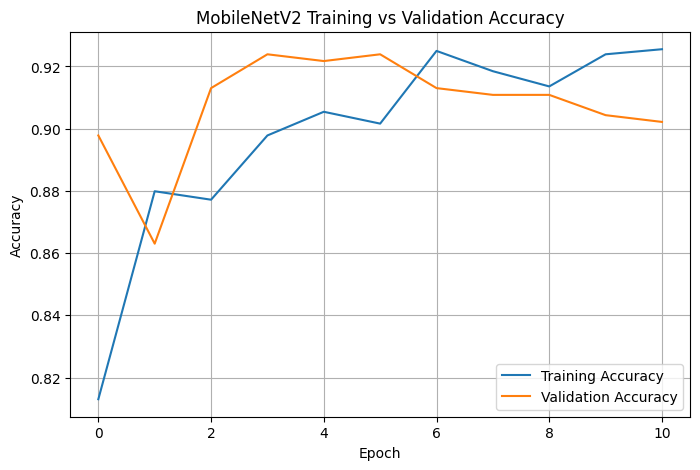

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Training vs Validation Loss

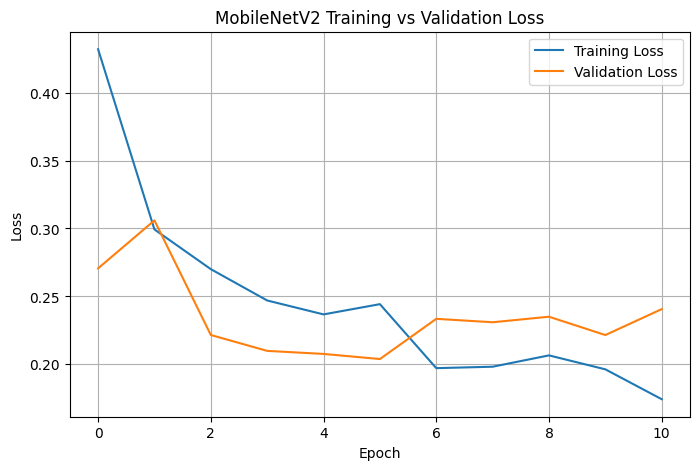

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Save MobileNetV2 Model

In [12]:
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the model
mobilenet_model.save("../models/mobilenetv2_car_damage_detection.keras")

print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


## CNN vs MobileNetV2 Performance Comparison

In [13]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["CNN (Scratch)", "MobileNetV2"],
    "Validation Accuracy": [82.83, 92.39]
})

comparison

,Model,Validation Accuracy
0,CNN (Scratch),82.83
1,MobileNetV2,92.39


## Conclusion

In this module, two deep learning models were developed for car damage classification. The first model was a CNN built from scratch, which achieved a validation accuracy of 82.83%. The second model used Transfer Learning with MobileNetV2 and achieved a higher validation accuracy of 92.39%. Based on the performance comparison, MobileNetV2 was selected as the final model because it provided better accuracy and generalization for car damage detection.